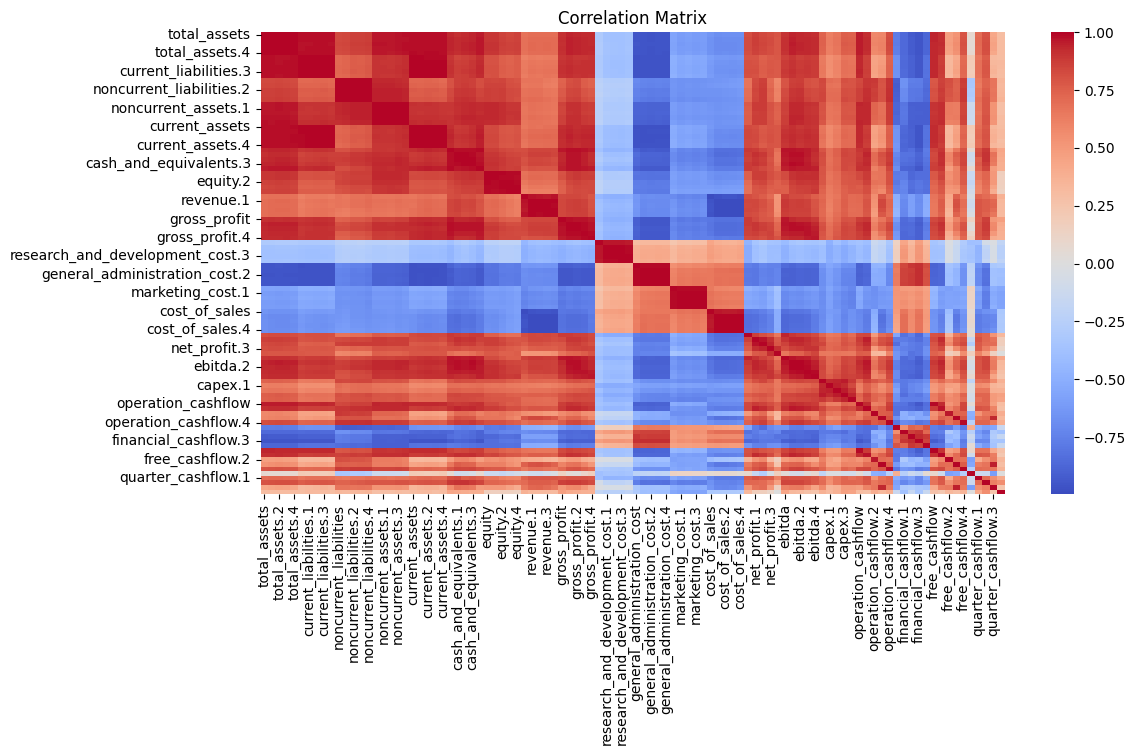

<ipython-input-25-4888e07dd725>:32: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  grouped_df = df_numeric.groupby(lambda x: x.split('.')[0], axis=1).mean()


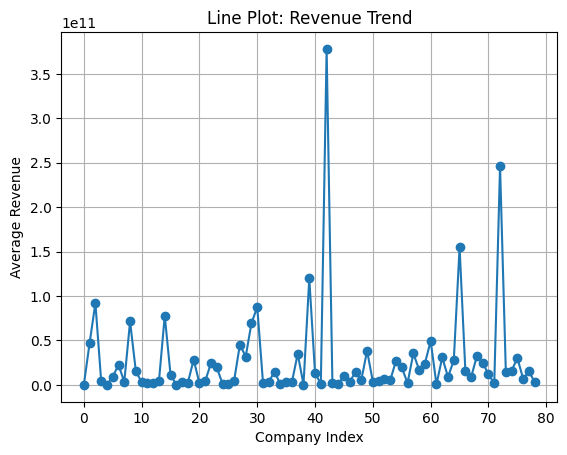

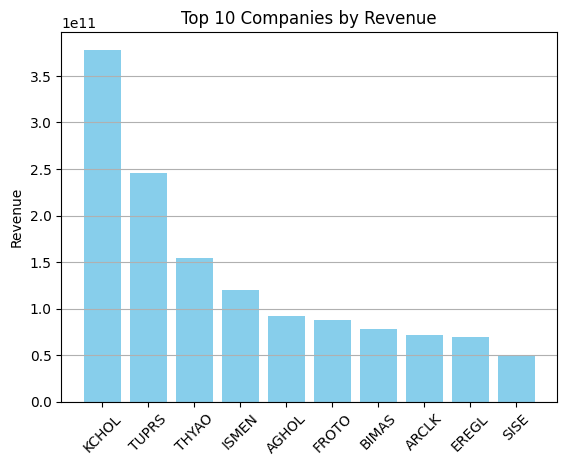

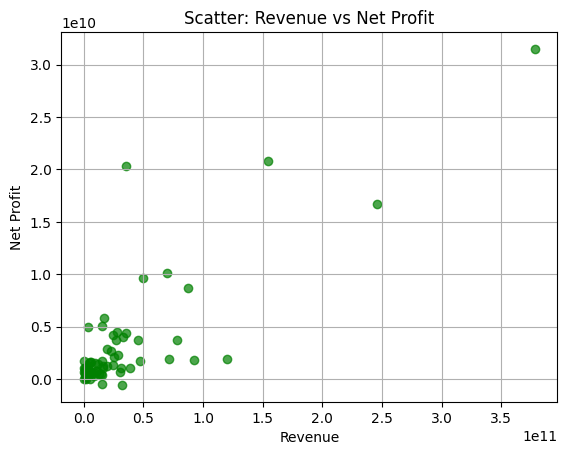


📉 Linear Regression
R²: 1.0
RMSE: 5.460528435652187e-06
MAE: 4.639838152797893e-06


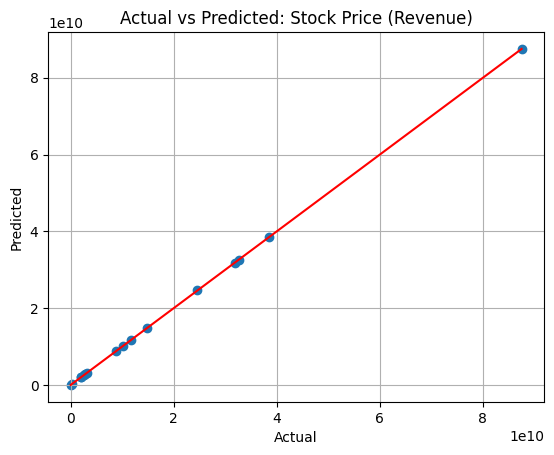

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:559: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  _index = to_datetime(index)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a 

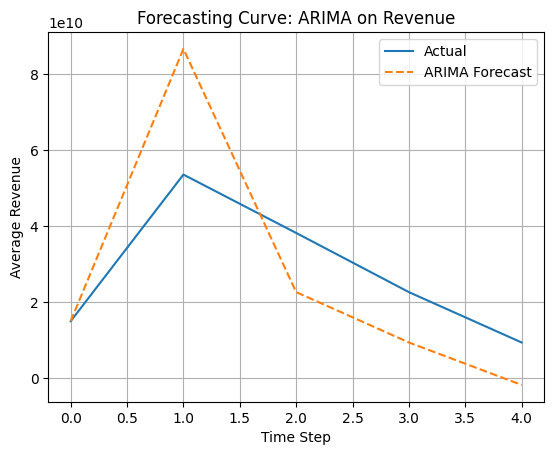


🏦 Logistic Regression
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0

🏦 Decision Tree
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0


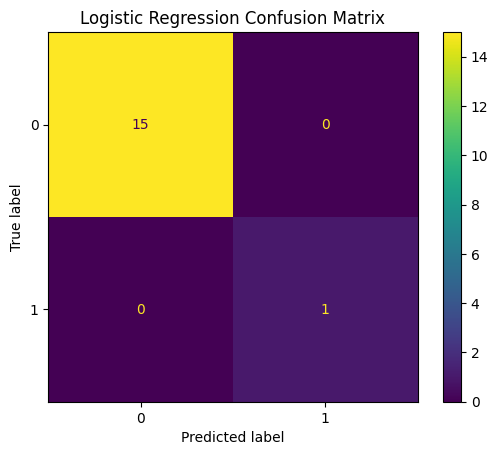

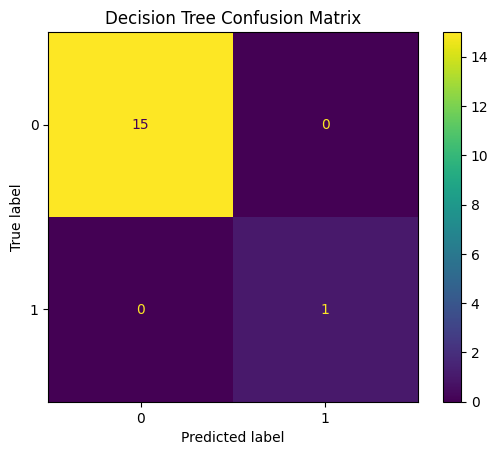


💰 Revenue Forecasting
R²: 0.2331574614867412
RMSE: 19230921875.416615
MAE: 13615777641.370739


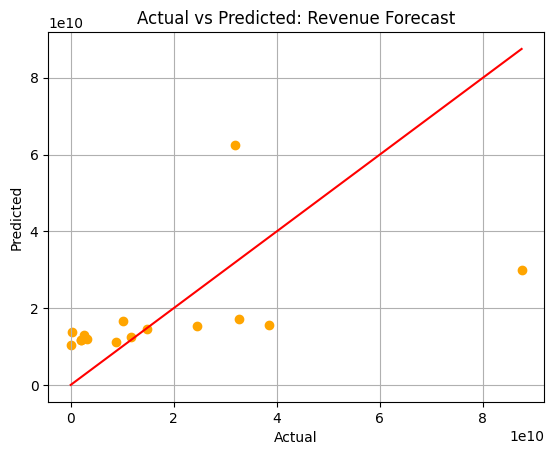

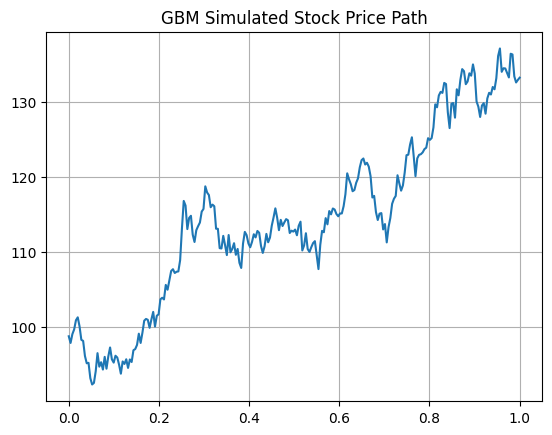


📈 Black-Scholes Call Price: 6.04
🌲 Binomial Tree Call Price: 6.06


In [25]:
# 📦 IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

from statsmodels.tsa.arima.model import ARIMA
from scipy.stats import norm



# 📥 LOAD DATA
df = pd.read_csv("BIST_financial_data.csv").dropna()
company_names = df['company_bist_code']
df_numeric = df.drop(columns=['company_bist_code'])

# 🔍 EDA - Correlation Matrix
plt.figure(figsize=(12, 6))
sns.heatmap(df_numeric.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# 🛠 FEATURE ENGINEERING
grouped_df = df_numeric.groupby(lambda x: x.split('.')[0], axis=1).mean()
grouped_df['company'] = company_names.values
grouped_df['default_risk'] = (grouped_df['net_profit'] < 0).astype(int)
grouped_df = grouped_df.dropna()

# 📈 Line Plot
plt.plot(grouped_df['revenue'].values, marker='o')
plt.title("Line Plot: Revenue Trend")
plt.xlabel("Company Index"); plt.ylabel("Average Revenue"); plt.grid(); plt.show()

# 📊 Bar Chart
top_rev = grouped_df.sort_values('revenue', ascending=False).head(10)
plt.bar(top_rev['company'], top_rev['revenue'], color='skyblue')
plt.xticks(rotation=45); plt.title("Top 10 Companies by Revenue")
plt.ylabel("Revenue"); plt.grid(axis='y'); plt.show()

# 🔘 Scatter Plot
plt.scatter(grouped_df['revenue'], grouped_df['net_profit'], c='green', alpha=0.7)
plt.title("Scatter: Revenue vs Net Profit"); plt.xlabel("Revenue"); plt.ylabel("Net Profit")
plt.grid(); plt.show()

# 📉 STOCK PRICE PREDICTION (Revenue Proxy)
X_price = grouped_df[['revenue', 'net_profit']]
y_price = grouped_df['revenue']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_price, y_price, test_size=0.2, random_state=42)
lr = LinearRegression().fit(X_train_p, y_train_p)
y_pred_lr = lr.predict(X_test_p)

print("\n📉 Linear Regression")
print("R²:", r2_score(y_test_p, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test_p, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test_p, y_pred_lr))

# 📊 Actual vs Predicted
plt.scatter(y_test_p, y_pred_lr)
plt.plot([y_test_p.min(), y_test_p.max()], [y_test_p.min(), y_test_p.max()], color='red')
plt.title("Actual vs Predicted: Stock Price (Revenue)")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(); plt.show()

# 🔮 Forecasting Curve - ARIMA
arima_series = df_numeric.filter(regex='^revenue').mean()
arima_model = ARIMA(arima_series, order=(2, 1, 0)).fit()
arima_forecast = arima_model.predict(start=1, end=len(arima_series))

plt.plot(arima_series.values, label='Actual')
plt.plot(arima_forecast.values, label='ARIMA Forecast', linestyle='--')
plt.title("Forecasting Curve: ARIMA on Revenue")
plt.xlabel("Time Step"); plt.ylabel("Average Revenue"); plt.legend(); plt.grid(); plt.show()

# 🏦 CREDIT RISK MODELING
X_clf = grouped_df[['total_assets', 'current_liabilities', 'revenue', 'net_profit']]
y_clf = grouped_df['default_risk']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression().fit(X_train_c, y_train_c)
y_pred_log = log_model.predict(X_test_c)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=4).fit(X_train_c, y_train_c)
y_pred_dt = dt_model.predict(X_test_c)

def print_clf_metrics(name, y_true, y_pred):
    print(f"\n🏦 {name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))

print_clf_metrics("Logistic Regression", y_test_c, y_pred_log)
print_clf_metrics("Decision Tree", y_test_c, y_pred_dt)

# Confusion Matrices
ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_log)
plt.title("Logistic Regression Confusion Matrix"); plt.grid(False); plt.show()

ConfusionMatrixDisplay.from_predictions(y_test_c, y_pred_dt)
plt.title("Decision Tree Confusion Matrix"); plt.grid(False); plt.show()

# 💰 REVENUE FORECASTING
X_rev = grouped_df[['total_assets', 'current_liabilities']]
y_rev = grouped_df['revenue']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_rev, y_rev, test_size=0.2, random_state=42)
rev_model = LinearRegression().fit(X_train_r, y_train_r)
y_pred_rev = rev_model.predict(X_test_r)

print("\n💰 Revenue Forecasting")
print("R²:", r2_score(y_test_r, y_pred_rev))
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, y_pred_rev)))
print("MAE:", mean_absolute_error(y_test_r, y_pred_rev))

# 📊 Revenue Forecast Actual vs Predicted
plt.scatter(y_test_r, y_pred_rev, color='orange')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], color='red')
plt.title("Actual vs Predicted: Revenue Forecast")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.grid(); plt.show()

# 🔁 GBM SIMULATION
def simulate_gbm(S0, mu, sigma, T, dt=1/252):
    N = int(T / dt)
    t = np.linspace(0, T, N)
    W = np.random.standard_normal(N).cumsum() * np.sqrt(dt)
    S = S0 * np.exp((mu - 0.5*sigma**2)*t + sigma*W)
    return t, S

t, S = simulate_gbm(100, 0.1, 0.2, 1)
plt.plot(t, S)
plt.title("GBM Simulated Stock Price Path")
plt.grid(); plt.show()

# 📈 BLACK-SCHOLES
def black_scholes_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

bs_price = black_scholes_call(100, 110, 1, 0.05, 0.2)
print("\n📈 Black-Scholes Call Price:", round(bs_price, 2))

# 🌲 BINOMIAL TREE
def binomial_tree_call(S, K, T, r, sigma, N):
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp(r*dt) - d) / (u - d)
    prices = np.zeros((N+1, N+1))
    for i in range(N+1):
        for j in range(i+1):
            prices[j, i] = S * (u ** (i-j)) * (d ** j)
    option = np.zeros_like(prices)
    option[:, N] = np.maximum(0, prices[:, N] - K)
    for i in range(N-1, -1, -1):
        for j in range(i+1):
            option[j, i] = np.exp(-r*dt) * (p * option[j, i+1] + (1-p) * option[j+1, i+1])
    return option[0, 0]

bt_price = binomial_tree_call(100, 110, 1, 0.05, 0.2, 50)
print("🌲 Binomial Tree Call Price:", round(bt_price, 2))



